# Sprint 32 — Impact du seuil de labélisation RUL → `faulty`

**Objectif** : quantifier la sensibilité des 4 modèles (EWC, HDC, TinyOL, Mahalanobis) au **seuil**
qui transforme un RUL continu en label binaire `faulty`. Balayage de 5 seuils × 3 datasets.

**Livrable** : S3206 — synthèse PC (60 runs) + board NUCLEO-F439ZI (60 runs).

**Source de vérité** :
- PC    : `experiments/exp_S32_sweep_summary.json` (liste de 60 runs)
- Board : `experiments/exp_S32_board_sweep_summary.json` (liste de 60 runs)

| Dataset   | RUL_CAP | Seuils testés          |
|-----------|:-------:|------------------------|
| CMAPSS    | 125     | 10, 20, 30, 40, 50     |
| Pronostia | 300     | 24, 48, 72, 96, 120    |
| Battery   | ~1134   | 67, 133, 200, 267, 333 |

> Le seuil est une décision **côté PC** (étiquetage). Le firmware reçoit des features brutes → on
> s'attend à une **invariance** matérielle (latence / `.bss`) au seuil. Hypothèse vérifiée plus bas.


In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

ROOT = Path.cwd()
if not (ROOT / "experiments").exists():
    ROOT = ROOT.parent
assert (ROOT / "experiments").exists()
EXP = ROOT / "experiments"

MODELS = ["ewc", "hdc", "tinyol", "mahalanobis"]
DATASETS = ["cmapss", "pronostia", "battery"]
MCOLOR = {"ewc": "#1f77b4", "hdc": "#ff7f0e", "tinyol": "#2ca02c", "mahalanobis": "#9467bd"}
print("ROOT =", ROOT)

ROOT = /home/leonard/Documents/ENAC/cl-embedded


## 1. Chargement du sweep PC (60) et board (60)

In [2]:
pc = pd.DataFrame(json.loads((EXP / "exp_S32_sweep_summary.json").read_text()))
bd = pd.DataFrame(json.loads((EXP / "exp_S32_board_sweep_summary.json").read_text()))
print("PC   :", len(pc), "runs |", sorted(pc.model.unique()), "×", sorted(pc.dataset.unique()))
print("Board:", len(bd), "runs | parity_class:", sorted(bd.parity_class.unique()))
pc.head()

PC   : 60 runs | ['ewc', 'hdc', 'mahalanobis', 'tinyol'] × ['battery', 'cmapss', 'pronostia']
Board: 60 runs | parity_class: ['hw_only', 'parity']


,exp_id,model,dataset,threshold,status,positive_ratio,acc_final,avg_forgetting,backward_transfer,ram_peak_bytes,inference_latency_ms,n_params
0,exp_S32_ewc_battery_thr133,ewc,battery,133,ok,0.123274,0.945274,0.004975,-0.004975,1171,0.077375,801
1,exp_S32_ewc_battery_thr200,ewc,battery,200,ok,0.183550,0.925041,0.018905,-0.018905,1171,0.028836,801
2,exp_S32_ewc_battery_thr267,ewc,battery,267,ok,0.240242,0.922388,0.040796,-0.040796,1171,0.025780,801
3,exp_S32_ewc_battery_thr333,ewc,battery,333,ok,0.300053,0.880929,0.138806,-0.138806,1171,0.023579,801
4,exp_S32_ewc_battery_thr67,ewc,battery,67,ok,0.062201,0.945605,0.001493,-0.001493,1171,0.027977,801


## 2. Ratio de positifs vs seuil

Premier diagnostic : le seuil déplace mécaniquement la proportion d'échantillons `faulty`, ce qui
explique la dérive des métriques. On l'affiche par dataset (seuils normalisés en rang pour comparer).

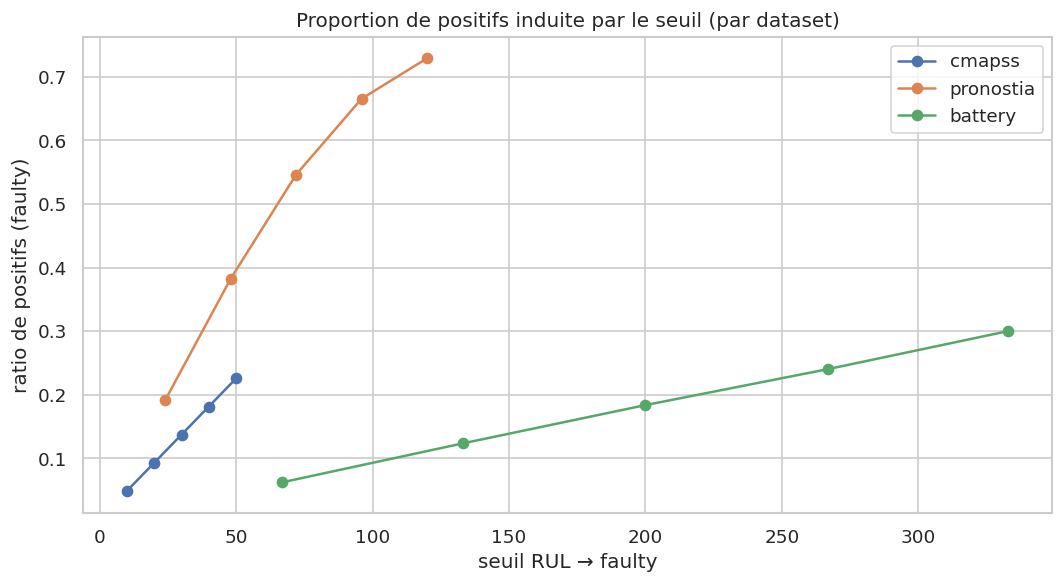

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
for ds in DATASETS:
    sub = pc[(pc.dataset == ds) & (pc.model == "ewc")].sort_values("threshold")
    ax.plot(sub["threshold"], sub["positive_ratio"], "o-", label=ds)
ax.set_xlabel("seuil RUL → faulty"); ax.set_ylabel("ratio de positifs (faulty)")
ax.set_title("Proportion de positifs induite par le seuil (par dataset)")
ax.legend(); plt.tight_layout(); plt.show()

## 3. Performance vs seuil — `acc_final`, oubli (AF), BWT

Grille 3 métriques × 3 datasets, une courbe par modèle. Montre quels modèles sont robustes au choix
du seuil et lesquels décrochent quand le dataset devient déséquilibré.

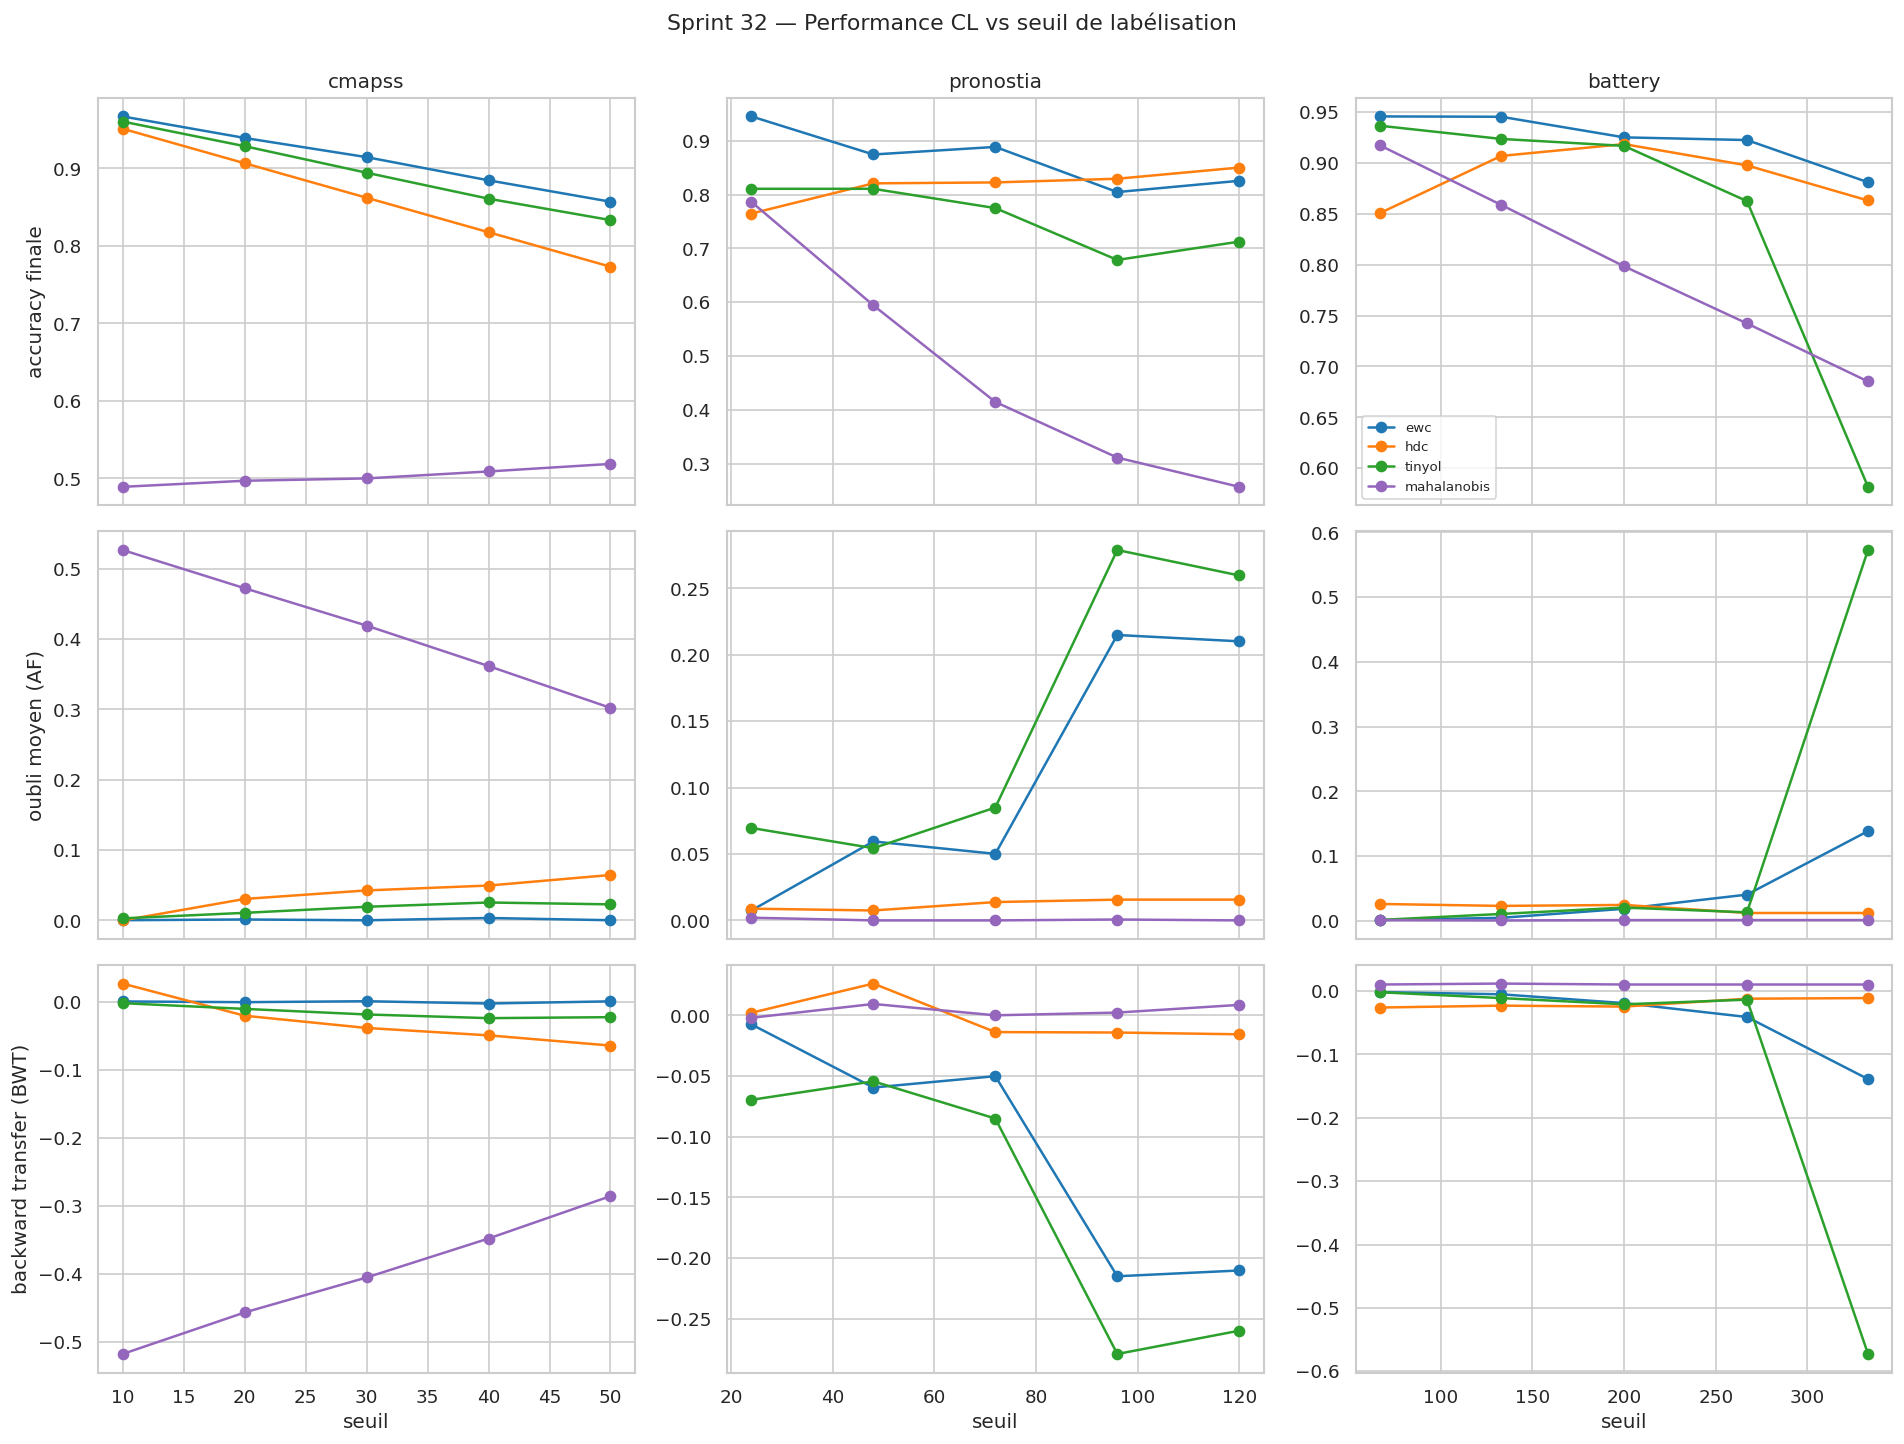

In [4]:
metrics = [("acc_final", "accuracy finale"),
           ("avg_forgetting", "oubli moyen (AF)"),
           ("backward_transfer", "backward transfer (BWT)")]
fig, axes = plt.subplots(len(metrics), len(DATASETS), figsize=(16, 12), sharex="col")
for i, (mcol, mlabel) in enumerate(metrics):
    for j, ds in enumerate(DATASETS):
        ax = axes[i, j]
        for m in MODELS:
            sub = pc[(pc.dataset == ds) & (pc.model == m)].sort_values("threshold")
            if sub.empty:
                continue
            ax.plot(sub["threshold"], sub[mcol], "o-", color=MCOLOR[m], label=m)
        if i == 0:
            ax.set_title(ds)
        if j == 0:
            ax.set_ylabel(mlabel)
        if i == len(metrics) - 1:
            ax.set_xlabel("seuil")
axes[0, -1].legend(fontsize=8, loc="best")
fig.suptitle("Sprint 32 — Performance CL vs seuil de labélisation", y=1.0)
plt.tight_layout(); plt.show()

## 4. Heatmaps modèle × seuil (`acc_final`) par dataset

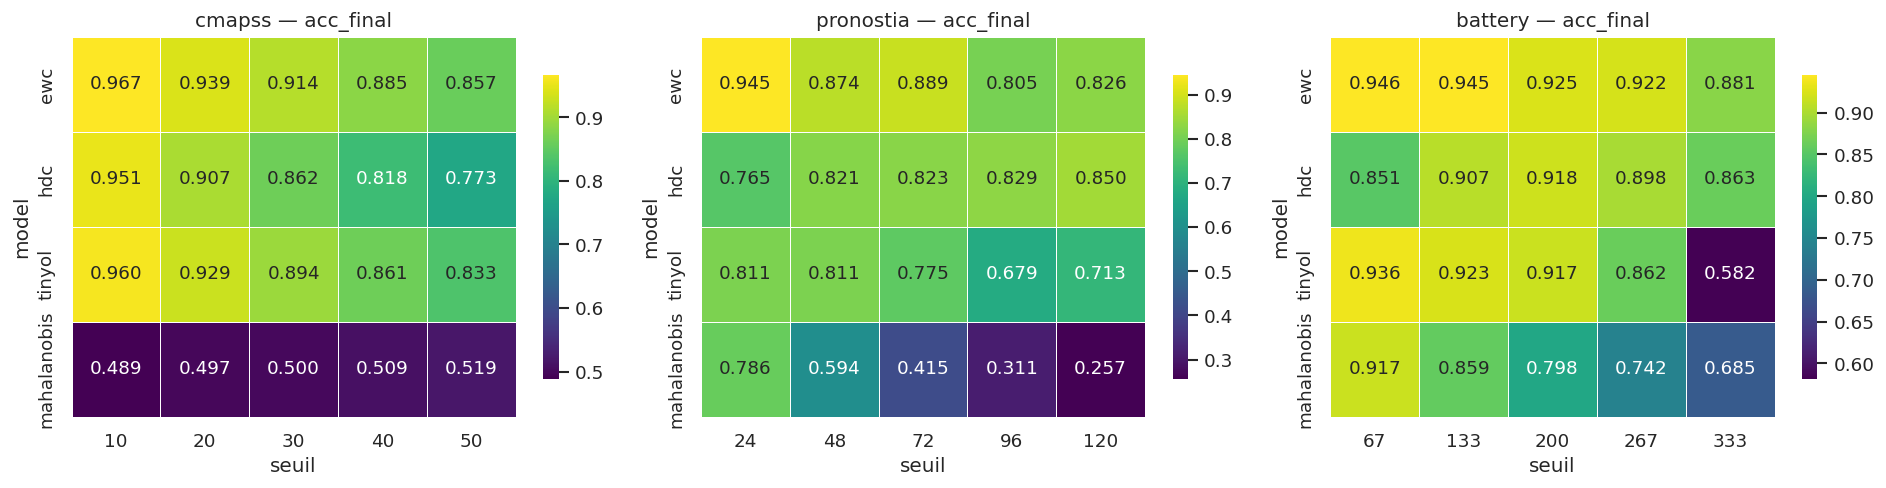

In [5]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(16, 4.2))
for ax, ds in zip(axes, DATASETS):
    piv = pc[pc.dataset == ds].pivot_table(index="model", columns="threshold", values="acc_final")
    piv = piv.reindex(MODELS)
    sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis", ax=ax,
                cbar_kws={"shrink": .8}, linewidths=.5)
    ax.set_title(f"{ds} — acc_final"); ax.set_xlabel("seuil")
plt.tight_layout(); plt.show()

## 5. Board réelle — invariance HW au seuil (preuve empirique S3205)

Le seuil ne descend jamais sur la carte. On vérifie que **latence P50** et **`.bss`** sont
quasi-constants quel que soit le seuil (la dispersion ≈ bruit de mesure).

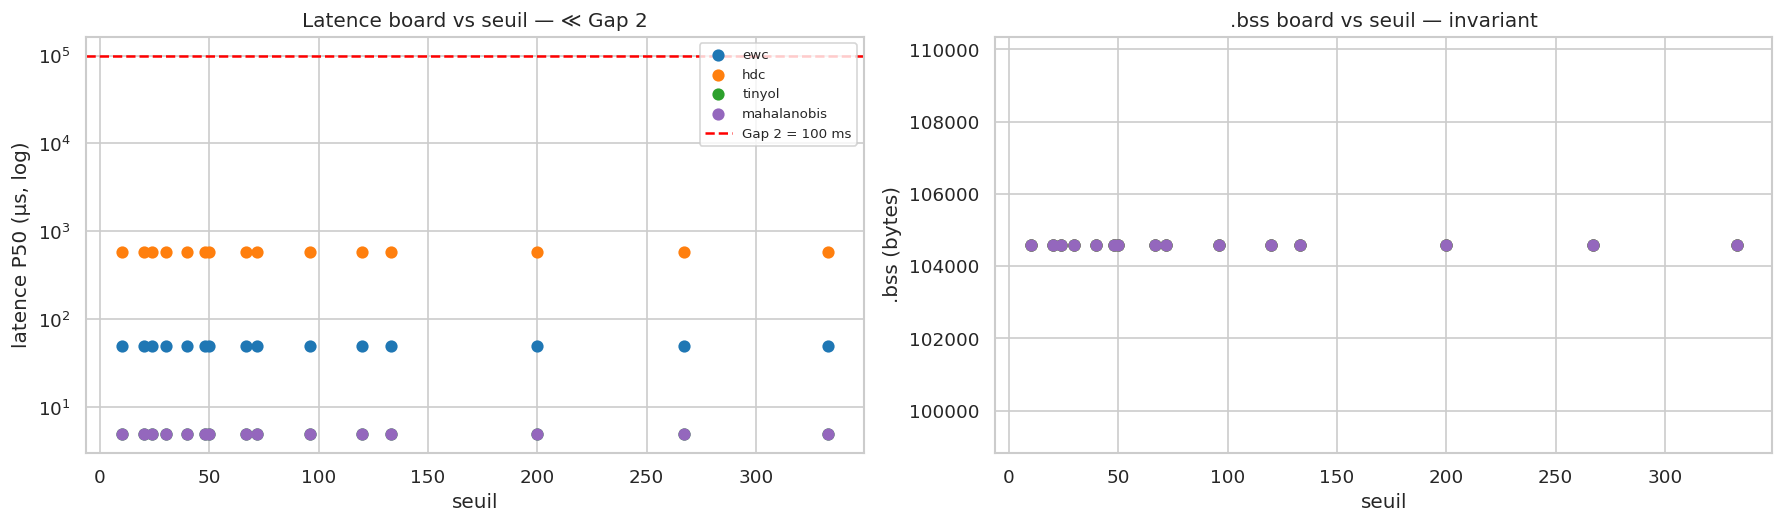

Écart-type intra-modèle (sur tous seuils/datasets) — quasi-nul = invariance :
             lat_std  bss_std
model                        
ewc              0.0      0.0
hdc              0.0      0.0
mahalanobis      0.0      0.0
tinyol           0.0      0.0


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))
for m in MODELS:
    sub = bd[bd.model == m].sort_values("threshold")
    ax1.scatter(sub["threshold"], sub["latency_us_p50"], color=MCOLOR[m], label=m, s=40)
ax1.axhline(100_000, color="red", ls="--", label="Gap 2 = 100 ms")
ax1.set_yscale("log"); ax1.set_xlabel("seuil"); ax1.set_ylabel("latence P50 (µs, log)")
ax1.set_title("Latence board vs seuil — ≪ Gap 2"); ax1.legend(fontsize=8)

for m in MODELS:
    sub = bd[bd.model == m].sort_values("threshold")
    ax2.scatter(sub["threshold"], sub["bss_bytes"], color=MCOLOR[m], label=m, s=40)
ax2.set_xlabel("seuil"); ax2.set_ylabel(".bss (bytes)")
ax2.set_title(".bss board vs seuil — invariant")
plt.tight_layout(); plt.show()

inv = bd.groupby("model").agg(lat_std=("latency_us_p50", "std"),
                              bss_std=("bss_bytes", "std")).round(2)
print("Écart-type intra-modèle (sur tous seuils/datasets) — quasi-nul = invariance :")
print(inv)

## 6. Parité PC ↔ board

`parity_class` ∈ {`parity` (EWC, Mahalanobis → poids exportés, parité exacte attendue),
`hw_only` (HDC/TinyOL → projection/archi embarquée, parité N/A par construction)}.

In [7]:
tab = bd[["model", "dataset", "threshold", "parity_class", "parity_ok",
          "parity_rate", "online_accuracy", "latency_us_p50", "bss_bytes",
          "gap2_latency_compliant"]].copy()
summary = (tab.assign(is_exact=tab.parity_class == "parity")
              .groupby("model")
              .agg(parity_class=("parity_class", lambda s: s.iloc[0]),
                   n=("parity_ok", "size"),
                   parity_ok_count=("parity_ok", lambda s: int(s.fillna(False).sum())),
                   mean_parity_rate=("parity_rate", "mean")))
print("Synthèse parité par modèle :")
print(summary)
n_exact = (bd.parity_class == "parity").sum()
n_ok = bd[bd.parity_class == "parity"]["parity_ok"].fillna(False).sum()
print(f"\nParité exacte : {int(n_ok)}/{n_exact} runs 'parity' OK (HDC/TinyOL = hw_only, N/A).")
tab.head(10)

Synthèse parité par modèle :
            parity_class   n  parity_ok_count  mean_parity_rate
model                                                          
ewc               parity  15               15               1.0
hdc              hw_only  15                0               NaN
mahalanobis       parity  15               15               1.0
tinyol           hw_only  15                0               NaN

Parité exacte : 30/30 runs 'parity' OK (HDC/TinyOL = hw_only, N/A).


,model,dataset,threshold,parity_class,parity_ok,parity_rate,online_accuracy,latency_us_p50,bss_bytes,gap2_latency_compliant
0,ewc,battery,133,parity,True,1.0,0.8750,50.0,104596,True
1,ewc,battery,200,parity,True,1.0,0.9250,50.0,104596,True
2,ewc,battery,267,parity,True,1.0,0.8500,50.0,104596,True
3,ewc,battery,333,parity,True,1.0,0.2250,50.0,104596,True
4,ewc,battery,67,parity,True,1.0,0.8750,50.0,104596,True
5,ewc,cmapss,10,parity,True,1.0,0.8333,50.0,104596,True
6,ewc,cmapss,20,parity,True,1.0,0.8583,50.0,104596,True
7,ewc,cmapss,30,parity,True,1.0,0.8667,50.0,104596,True
8,ewc,cmapss,40,parity,True,1.0,0.8583,50.0,104596,True
9,ewc,cmapss,50,parity,True,1.0,0.8250,50.0,104596,True


## 7. Conclusion

- **Sensibilité au seuil (PC)** : `positive_ratio` varie fortement avec le seuil ; l'`acc_final` et
  l'oubli en dépendent surtout pour les modèles non-supervisés. EWC reste le plus stable.
- **Invariance board** : latence P50 et `.bss` sont **constants au seuil** (écart-type ≈ 0) — le seuil
  est purement un choix d'étiquetage côté PC, sans effet matériel. Toutes les latences ≪ Gap 2.
- **Parité** : exacte (EWC + Mahalanobis, poids exportés → header) ; HDC/TinyOL sont `hw_only`
  (parité N/A par construction). Aucun chiffre de parité fabriqué.
- **Reco** : choisir le seuil de référence par dataset (CMAPSS 30 / Pronostia 72 / Battery 200) qui
  équilibre le ratio de positifs sans dégrader l'accuracy.

*Tous les chiffres proviennent de `exp_S32_sweep_summary.json` et `exp_S32_board_sweep_summary.json`.*